# Регуляризація та функції активації в нейронних мережах

## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.
## Завдання 1
Дослідіть вплив функцій активації на результати моделі.
- Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
- Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
- Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
- Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
- Оформіть результати в таблиці:

|Активація|MAE|R²|
|-|-|-|
|ReLU|...|..|
|Tanh|...|...
|LeakyReLU|...|...|
|Swish|...|...|

In [30]:
# підготовка даних:
# 1. Генерація
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
# 2. Поділ на навчальну та тестову групи
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
# 3. Нормалізація (масштабування)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)
# 4. Перетворення на тензори, з якими працює нейромережа
import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.01  # ручне масштабування
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.01    # без нього не всі моделі навчаються
xtrain[:5]

tensor([[-1.4218, -1.7382,  2.2573,  0.9371, -0.1872, -0.4124, -0.8198,  0.5330,
          2.0658, -0.6393],
        [ 0.7167,  2.4002,  0.1762, -1.2007, -0.1304, -0.2881,  0.4266, -0.5240,
         -1.6228, -2.7448],
        [ 0.8954,  0.2904, -1.0853, -0.0613,  0.3031,  1.3613,  0.6415,  1.4155,
         -1.0867,  1.4703],
        [ 0.1449,  1.4552, -0.8136,  0.8235, -0.6888,  1.3535,  0.1819,  1.4001,
         -0.5187,  1.3550],
        [ 0.2664, -1.0402, -0.9091, -1.0444,  1.2611, -0.6352, -0.3055,  1.6526,
          0.7376,  0.2739]])

In [31]:
# Готуємо різні функції активації
import torch.nn as nn
activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [32]:
# Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
class Mlp(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(Mlp, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )

    def forward(self,x) :
        return self.layers(x)
        

In [33]:
# Функція для навчання моделей
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(),lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) :
        output = model(X)   # model.forward(X)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses    

In [34]:
# Послідовно застосуйте різні функції активації
mlps = { k: Mlp(activation=k) for k in activators.keys() }
# mlps

In [35]:
losses = {}
predictions = {}
for k, mlp in mlps.items() :
    losses[k] = train_model(mlp, xtrain, ytrain)  # навчаємо всі моделі та зберігаємо їх прогреси (втрати)
    with torch.no_grad() :
        predictions[k] = mlp(xtest)

print(*zip(*(predictions[k][:5] for k in mlps.keys() ), ytest[:5]),sep='\n')

(tensor([-0.2124]), tensor([-0.2632]), tensor([-0.2933]), tensor([-0.0622]), tensor([-0.1030]), tensor([-0.1895]), tensor([-0.4273]))
(tensor([-3.1685]), tensor([-3.0276]), tensor([-3.2890]), tensor([-3.1569]), tensor([-3.1949]), tensor([-3.1283]), tensor([-3.1473]))
(tensor([1.5679]), tensor([1.6774]), tensor([1.6592]), tensor([1.4930]), tensor([1.4497]), tensor([1.4937]), tensor([1.5193]))
(tensor([-2.2021]), tensor([-2.1078]), tensor([-2.0005]), tensor([-2.2212]), tensor([-2.0001]), tensor([-2.3366]), tensor([-2.3265]))
(tensor([3.8186]), tensor([3.9071]), tensor([4.0481]), tensor([3.8646]), tensor([3.9476]), tensor([4.0067]), tensor([4.0800]))


Без масштабування вихідних даних (у) деякі моделі не проходять навчання
Функції активації типу ReLU не обмежені, через що відбувається переповнення коефіцієнтів 


In [41]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

md("\n".join((
    "|Активація|MAE|R²|",
    "|-|-|-|",
    *(f"|{k}|{sm.mean_absolute_error(ytest,v)}|{sm.r2_score(ytest,v)}|" for k,v in predictions.items())
)))

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.12536396086215973|0.9925832748413086|
|ReLU|0.14763858914375305|0.9916775822639465|
|Tanh|0.14489620923995972|0.990979790687561|
|LeakyReLU|0.1449568122625351|0.991671621799469|
|SiLU|0.10176768153905869|0.995881199836731|
|Swish|0.10064294934272766|0.9960693717002869|

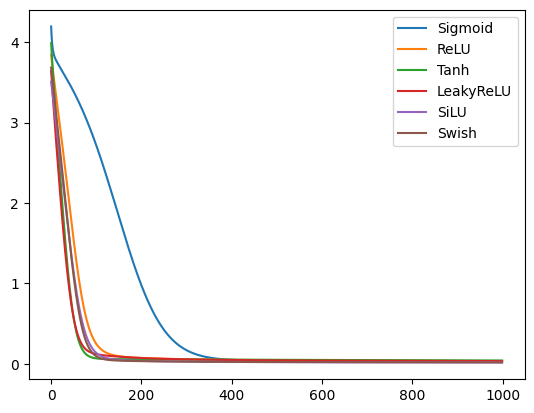

In [43]:
# Побудувати лінії втрат (losses) на одному графіку. Назви додати як легенду
import matplotlib.pyplot as plt
_,ax = plt.subplots()
for k,v in losses.items() :
    ax.plot(v, label=k)
ax.legend()    
plt.show()